In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')

import h5py
import numpy as np
import matplotlib.pyplot as plt
from spook import SpookLinSolve, SpookPosL1

## 1. Load data

In [2]:
H5 = 'examples/results/mfx101609126_pershot_xes/run0079.h5'

with h5py.File(H5, 'r') as f:
    xrt_raw      = f['xrt_hproj'][:]       # (N, 2048) — incident spectrum
    epix_spec    = f['epix_spec_ROI_1'][:]  # (N, 300)  — emission (epix100_0)
    epix_seer    = f['epix_seer_ROI_1'][:]  # (N, 620)  — emission (epix100_1 SEER)
    ipm          = f['ipm'][:]              # (N,)

print(f'Shots: {xrt_raw.shape[0]}')
print(f'xrt_raw:   {xrt_raw.shape}')
print(f'epix_spec: {epix_spec.shape}')
print(f'epix_seer: {epix_seer.shape}')

Shots: 2843
xrt_raw:   (2843, 2048)
epix_spec: (2843, 300)
epix_seer: (2843, 620)


## 2. Inspect mean spectra and shot-to-shot variance
Verify signal is present in the chosen emission detector before running spook.

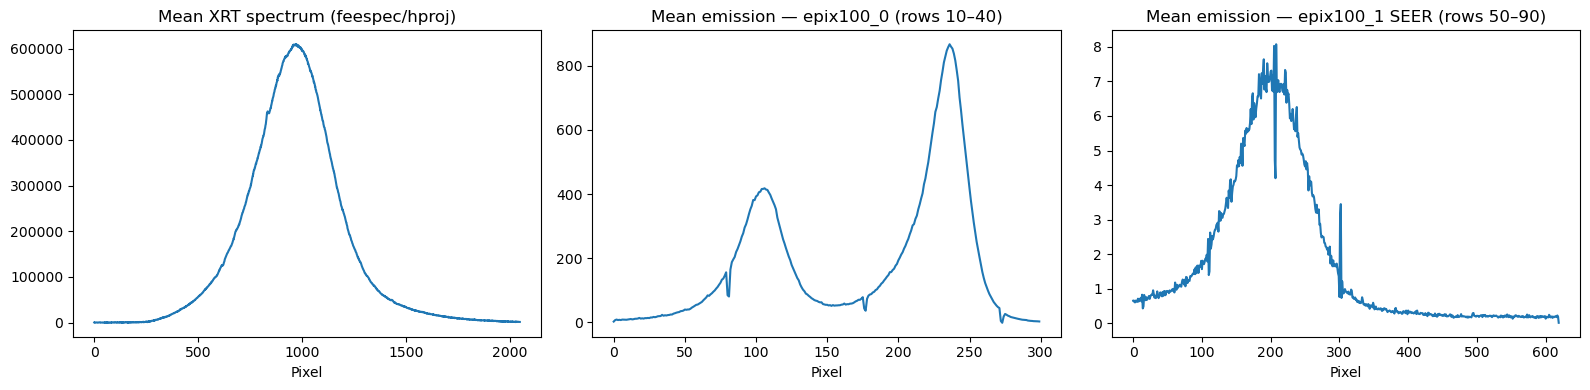

XRT CoM: mean=971.4  std=136.15 px  (14.0% variation)
(Need >~1% for stochastic RIXS to work)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(xrt_raw.mean(axis=0))
axes[0].set_title('Mean XRT spectrum (feespec/hproj)')
axes[0].set_xlabel('Pixel')

axes[1].plot(epix_spec.mean(axis=0))
axes[1].set_title('Mean emission — epix100_0 (rows 10–40)')
axes[1].set_xlabel('Pixel')

axes[2].plot(epix_seer.mean(axis=0))
axes[2].set_title('Mean emission — epix100_1 SEER (rows 50–90)')
axes[2].set_xlabel('Pixel')

plt.tight_layout()
plt.show()

# Shot-to-shot energy variation in XRT
px = np.arange(xrt_raw.shape[1], dtype=float)
total_xrt = xrt_raw.sum(axis=1)
com_xrt = (xrt_raw @ px) / np.where(total_xrt > 0, total_xrt, 1)
print(f'XRT CoM: mean={com_xrt.mean():.1f}  std={com_xrt.std():.2f} px  ({com_xrt.std()/com_xrt.mean()*100:.1f}% variation)')
print('(Need >~1% for stochastic RIXS to work)')

## 3. Prepare A (incident) and B (emission) matrices

Key steps:
1. **Crop XRT** to the active pixel range (avoids zero-only columns inflating AtA)
2. **Bin XRT** to reduce the problem size for OSQP (8× → ~190 bins)  
3. **Mean-subtract both A and B** — isolates shot-to-shot fluctuations; removes the mean spectrum which dominates AtA and makes it ill-conditioned

Choose which emission detector to use as `B` below.

In [4]:
# --- User settings ---
XRT_PIXEL_START = 301   # active XRT range (from inspection above)
XRT_PIXEL_END   = 1833
XRT_BIN         = 8     # bin factor: 2048 → ~191 bins

# Choose emission detector: epix_spec or epix_seer
B_raw = epix_spec        # swap to epix_seer to use SEER spectrometer
#B_raw = epix_seer
# ---------------------

# Crop and bin XRT
A_crop = xrt_raw[:, XRT_PIXEL_START:XRT_PIXEL_END]
n_bins = (A_crop.shape[1] // XRT_BIN)
A_binned = A_crop[:, :n_bins*XRT_BIN].reshape(A_crop.shape[0], n_bins, XRT_BIN).sum(axis=2)

# Mean-subtract to isolate shot-to-shot fluctuations
A = A_binned - A_binned.mean(axis=0)
B = B_raw    - B_raw.mean(axis=0)

print(f'A (incident fluctuations): {A.shape}')
print(f'B (emission fluctuations): {B.shape}')

A (incident fluctuations): (2843, 191)
B (emission fluctuations): (2843, 300)


## 4. Contract: eliminate the shot dimension

In [5]:
AtA   = A.T @ A          # (N_incident_bins, N_incident_bins)
AtB   = A.T @ B          # (N_incident_bins, N_emission_px)
TrBtB = float(np.sum(B**2))

print(f'AtA: {AtA.shape}  (condition number: {np.linalg.cond(AtA):.2e})')
print(f'AtB: {AtB.shape}  max signal: {AtB.max():.2e}')

AtA: (191, 191)  (condition number: 7.06e+08)
AtB: (191, 300)  max signal: 3.27e+12


## 5. Run spook

Two solvers available:
- **`SpookLinSolve`** — fast, L2 regularization, no positivity constraint. Good for first look and hyperparameter exploration.
- **`SpookPosL1`** — physically correct (non-negative + sparse), uses OSQP. Slow but proper. Needs binned XRT (≤ ~256 bins) to fit in memory.

Tune `lsparse` and `lsmooth` to balance resolution vs noise.

In [6]:
# --- Fast L2 solve (good starting point) ---
spk = SpookLinSolve(AtB, AtA, mode='contracted', lsmooth=(1e-3, 1e-3))
#spk = SpookPosL1(AtB, AtA, mode='contracted', lsmooth=(1e-3, 1e-3))
spk.set_btb(TrBtB)
X_l2 = spk.getXopt()
print(f'L2 RIXS map: {X_l2.shape}  max={X_l2.max():.3e}')

L2 RIXS map: (191, 300)  max=7.127e-06


In [7]:
# --- L1 + positivity (SpookPosL1) — set bin factor ≥ 8 to fit in memory ---
# spk_pos = SpookPosL1(AtB, AtA, mode='contracted', lsparse=1.0, lsmooth=(0.1, 0.1))
# spk_pos.set_btb(TrBtB)
# X_pos = spk_pos.getXopt()
# print(f'L1-pos RIXS map: {X_pos.shape}')

## 6. Plot RIXS map

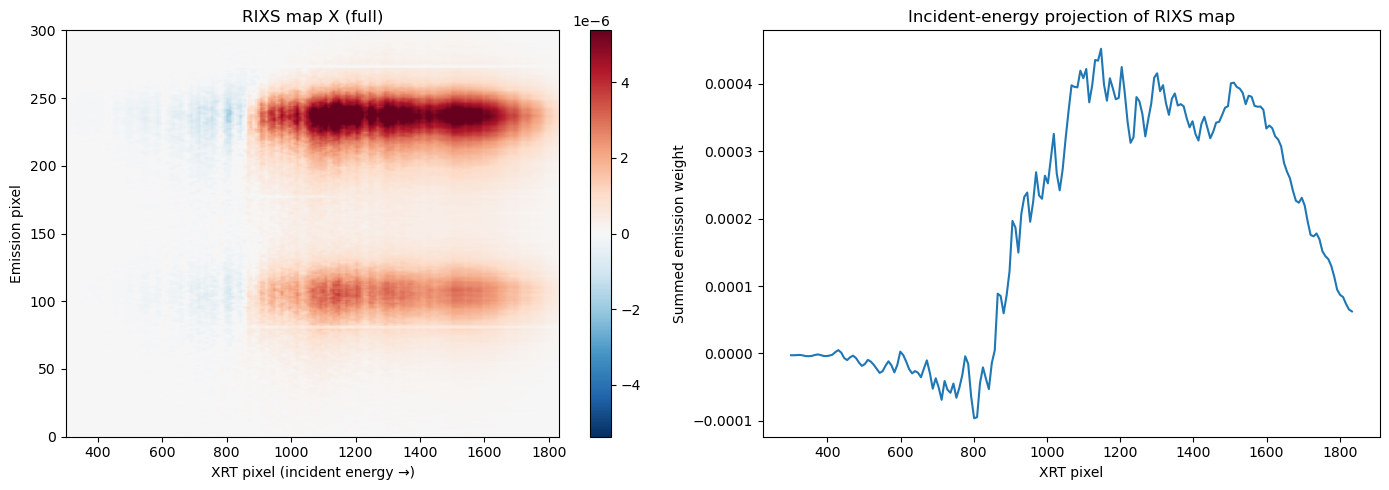

In [8]:
X = X_l2   # swap to X_pos once SpookPosL1 runs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full map
im = axes[0].imshow(X.T, aspect='auto', origin='lower',
                    extent=[XRT_PIXEL_START, XRT_PIXEL_END, 0, B.shape[1]],
                    cmap='RdBu_r', vmin=-np.percentile(np.abs(X), 99), vmax=np.percentile(np.abs(X), 99))
plt.colorbar(im, ax=axes[0])
axes[0].set_xlabel('XRT pixel (incident energy →)')
axes[0].set_ylabel('Emission pixel')
axes[0].set_title('RIXS map X (full)')

# Diagonal / elastic line projection
diag_proj = X.sum(axis=1)
axes[1].plot(np.linspace(XRT_PIXEL_START, XRT_PIXEL_END, len(diag_proj)), diag_proj)
axes[1].set_xlabel('XRT pixel')
axes[1].set_ylabel('Summed emission weight')
axes[1].set_title('Incident-energy projection of RIXS map')

plt.tight_layout()
plt.show()

## Notes for Fe foil RIXS

- If `X` is near-zero, the ROI (rows 10–40 / 50–90) may not be capturing the Fe Kβ emission (~7058 eV). Run the `mfx101609126_seer_vs_xrt.ipynb` first to find where the signal actually sits in Y, then update the YAML `rois:` and rerun the pipeline.
- Try swapping `B_raw = epix_seer` — the SEER spectrometer may have better energy resolution for Kβ RIXS.
- If CoM–CoM correlation between XRT and emission is < 0.1, the stochastic deconvolution will return a flat/noisy map regardless of regularization. Verify the beam was on sample during run 79.
- Hyperparameter sweep: re-solve cheaply with cached AtA/AtB — `spk.getXopt(lsmooth=(x, y))` doesn't recontract.